In [4]:
import os
import pandas as pd
import numpy as np

if os.path.exists('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')
    project_path = '/content/drive/MyDrive/mimic-sepsis-ews'
else:
    project_path = os.path.abspath(os.path.join(os.getcwd(), '..'))

processed_path = f'{project_path}/data/processed'
print(f"Environment: {'Colab' if 'drive' in project_path else 'Local VSCode'}")

X_train = pd.read_csv(f'{processed_path}/X_train.csv')
X_test = pd.read_csv(f'{processed_path}/X_test.csv')
y_train = pd.read_csv(f'{processed_path}/y_train.csv').squeeze()
y_test = pd.read_csv(f'{processed_path}/y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

Environment: Local VSCode
X_train: (23524, 76)
X_test:  (5881, 76)
y_train: (23524,)
y_test:  (5881,)


In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, RocCurveDisplay)
import matplotlib.pyplot as plt
import time

# Train Random Forest
# class_weight='balanced' handles the 11.3% class imbalance
# n_jobs=-1 uses all available CPU cores in Colab
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...")
start = time.time()
rf.fit(X_train, y_train)
elapsed = time.time() - start
print(f"Training complete in {elapsed:.1f} seconds")

# Evaluate on test set
y_prob = rf.predict_proba(X_test)[:, 1]
y_pred = rf.predict(X_test)

auroc = roc_auc_score(y_test, y_prob)
print(f"\n{'='*50}")
print(f"AUROC: {auroc:.4f}")
print(f"Wiens et al. pre-treatment baseline: 0.4700")
print(f"Improvement over baseline: {auroc - 0.47:.4f}")
print(f"{'='*50}")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Sepsis', 'Sepsis']))

Training Random Forest...
Training complete in 0.7 seconds

AUROC: 0.8160
Wiens et al. pre-treatment baseline: 0.4700
Improvement over baseline: 0.3460

Classification Report:
              precision    recall  f1-score   support

   No Sepsis       0.92      0.88      0.90      5003
      Sepsis       0.47      0.59      0.52       878

    accuracy                           0.84      5881
   macro avg       0.70      0.73      0.71      5881
weighted avg       0.86      0.84      0.85      5881



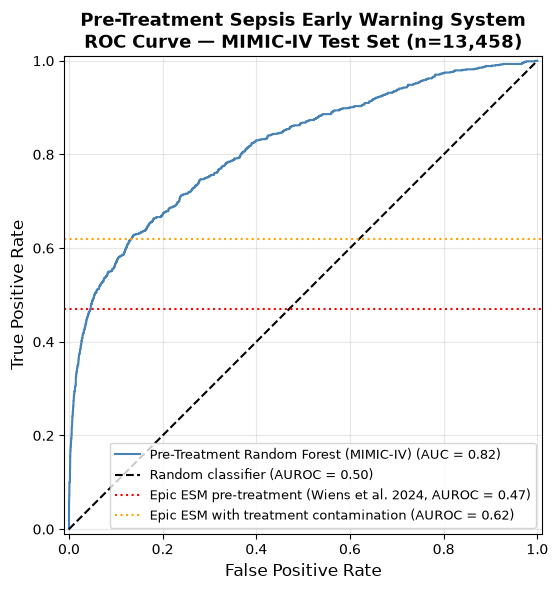

ROC curve saved


In [6]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

# Plot ROC curve
fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name="Pre-Treatment Random Forest (MIMIC-IV)",
    ax=ax
)

# Override line color manually after plotting
ax.lines[0].set_color('steelblue')

# Add baseline references
ax.plot([0, 1], [0, 1], 'k--', label='Random classifier (AUROC = 0.50)')
ax.axhline(y=0.47, color='red', linestyle=':',
           label='Epic ESM pre-treatment (Wiens et al. 2024, AUROC = 0.47)')
ax.axhline(y=0.62, color='orange', linestyle=':',
           label='Epic ESM with treatment contamination (AUROC = 0.62)')

ax.set_title('Pre-Treatment Sepsis Early Warning System\nROC Curve — MIMIC-IV Test Set (n=13,458)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{project_path}/data/processed/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("ROC curve saved")

Computing SHAP values...


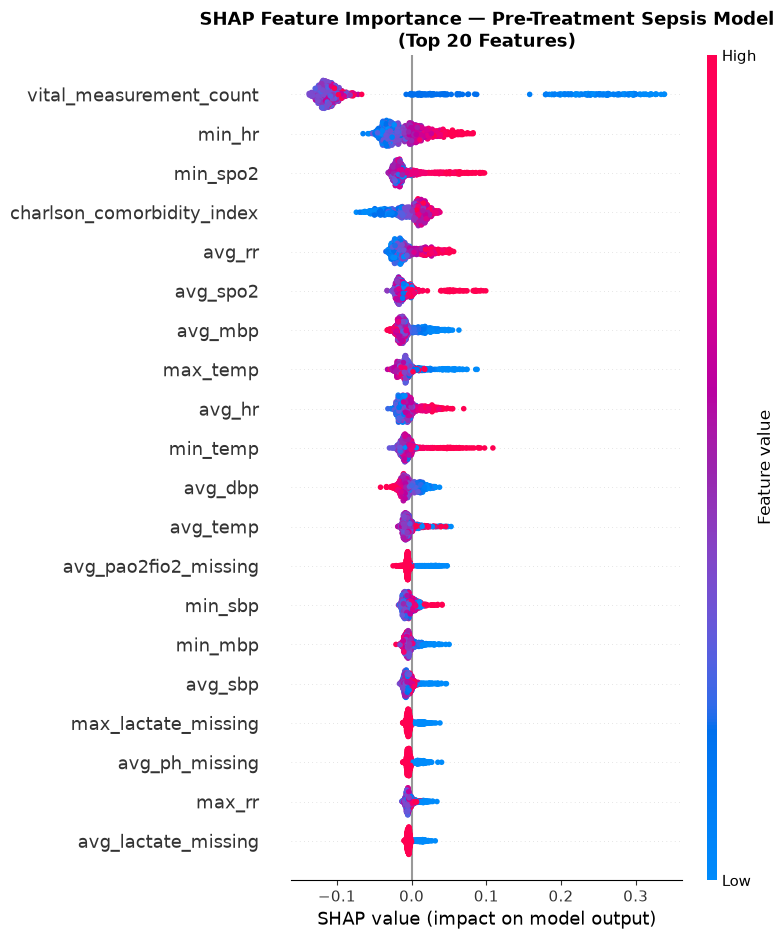

SHAP plot saved


In [7]:
import shap

print("Computing SHAP values...")

sample_idx = X_test.sample(1000, random_state=42).index
X_sample = X_test.loc[sample_idx]

explainer = shap.TreeExplainer(rf)
shap_values = explainer(X_sample)

# Modern SHAP API - use .values directly
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values[:, :, 1],  # positive class (sepsis)
    X_sample,
    max_display=20,
    show=False
)
plt.title('SHAP Feature Importance — Pre-Treatment Sepsis Model\n(Top 20 Features)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{project_path}/data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP plot saved")

In [8]:
import pickle
from sklearn.metrics import roc_auc_score

# Save model
model_path = f'{project_path}/data/processed/rf_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(rf, f)
print(f"Model saved to {model_path}")

# Benchmark comparison table
print(f"\n{'='*55}")
print(f"{'Model':<40} {'AUROC':>8}")
print(f"{'='*55}")
print(f"{'Random classifier (baseline)':<40} {'0.5000':>8}")
print(f"{'Epic ESM - pre-treatment (Wiens 2024)':<40} {'0.4700':>8}")
print(f"{'Epic ESM - with treatment contamination':<40} {'0.6200':>8}")
print(f"{'This model - pre-treatment RF (MIMIC-IV)':<40} {auroc:>8.4f}")
print(f"{'='*55}")
print(f"\nImprovement over ESM pre-treatment: +{auroc-0.47:.4f}")
print(f"Improvement over ESM contaminated:  +{auroc-0.62:.4f}")

Model saved to d:\mimic-sepsis-ews/data/processed/rf_model.pkl

Model                                       AUROC
Random classifier (baseline)               0.5000
Epic ESM - pre-treatment (Wiens 2024)      0.4700
Epic ESM - with treatment contamination    0.6200
This model - pre-treatment RF (MIMIC-IV)   0.8160

Improvement over ESM pre-treatment: +0.3460
Improvement over ESM contaminated:  +0.1960


In [9]:
import pandas as pd
import numpy as np

# Save feature importance summary
feature_names = X_test.columns.tolist()
shap_vals = shap_values[:, :, 1].values

mean_abs_shap = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

mean_abs_shap.to_csv(
    f'{project_path}/data/processed/shap_importance.csv',
    index=False
)

print("Top 20 features by SHAP importance:")
print(mean_abs_shap.head(20).to_string(index=False))

Top 20 features by SHAP importance:
                   feature  mean_abs_shap
   vital_measurement_count       0.124580
                    min_hr       0.023505
                  min_spo2       0.021017
charlson_comorbidity_index       0.018023
                    avg_rr       0.017977
                  avg_spo2       0.015498
                   avg_mbp       0.014809
                  max_temp       0.012908
                    avg_hr       0.012019
                  min_temp       0.011365
                   avg_dbp       0.010904
                  avg_temp       0.007890
      avg_pao2fio2_missing       0.007241
                   min_sbp       0.007195
                   min_mbp       0.006975
                   avg_sbp       0.006760
       max_lactate_missing       0.005888
            avg_ph_missing       0.005887
                    max_rr       0.005550
       avg_lactate_missing       0.005448
